# 05 — Machine-learning models *(partial: RF + XGBoost, 1-day horizon)*

**Scope of this partial run.** Random forest and XGBoost at the **1-day horizon**,
per site, to give RQ1 a preliminary ML-vs-classical comparison for the interim
report. Hyperparameters are tuned with a small grid under **time-series
cross-validation on the training window only** (expanding-window splits, no
shuffling). Still pending for the final report: the LSTM (30-day windows), the
7-day horizon, and fuller tuning.

**Leakage control.** Direct forecasting strategy: to predict GHI on day *t+1*,
every feature is measured on or before the origin day *t* — today's GHI and its
lags 1–6, the 7-/30-day rolling means, today's five meteorological variables, and
the day-of-year harmonics of the origin day. Split (from `src/config.py`): train
2005–2020, validation 2021–2022; the 2023–2024 **test set stays untouched** until
notebook 06.

In [1]:
import sys, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, DATA_PROCESSED, RESULTS, TRAIN_END, VAL_END)

TARGET = 'ALLSKY_SFC_SW_DWN'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})


## 5.1 Feature matrix (all features known at the origin day *t*)

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')
train_end = pd.Timestamp(TRAIN_END)
val_end = pd.Timestamp(VAL_END)

MET = ['T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOTCORR', 'WS2M']
FEATURES = ([TARGET]                                  # today's GHI (lag 0 w.r.t. origin)
            + [f'ghi_lag{l}' for l in range(1, 7)]    # y_{t-1} … y_{t-6}
            + ['ghi_roll7', 'ghi_roll30']             # rolling means up to t
            + MET                                     # today's weather
            + ['doy_sin', 'doy_cos'])                 # calendar position

def make_xy(site_df, horizon=1):
    X = site_df[FEATURES].copy()
    y = site_df[TARGET].shift(-horizon)               # target = GHI at t + h
    ok = X.notna().all(axis=1) & y.notna()
    return X[ok], y[ok]

def metrics(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    mae = float(np.mean(np.abs(y - yhat)))
    r2 = float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))
    return rmse, mae, r2

print(f'{len(FEATURES)} features:', FEATURES)

16 features: ['ALLSKY_SFC_SW_DWN', 'ghi_lag1', 'ghi_lag2', 'ghi_lag3', 'ghi_lag4', 'ghi_lag5', 'ghi_lag6', 'ghi_roll7', 'ghi_roll30', 'T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOTCORR', 'WS2M', 'doy_sin', 'doy_cos']


## 5.2 Models and time-series cross-validated tuning

Small, honest grids (this is a preliminary pass — refined tuning is scheduled for
the final report). `TimeSeriesSplit(3)` keeps every validation fold strictly
after its training fold.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

CV = TimeSeriesSplit(n_splits=3)

GRIDS = {
    'Random forest': (
        RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
        {'max_depth': [10, None], 'min_samples_leaf': [1, 5]}),
    'XGBoost': (
        XGBRegressor(n_estimators=500, learning_rate=0.05, objective='reg:squarederror',
                     random_state=42, n_jobs=-1, verbosity=0),
        {'max_depth': [3, 6], 'subsample': [0.8, 1.0]}),
}

rows = []
best_params = {}
importances = {}
preds_store = {}

for key in SITE_ORDER:
    sdf = df[df['site'] == key]
    X, y = make_xy(sdf, horizon=1)
    X_tr, y_tr = X[X.index <= train_end], y[X.index <= train_end]
    val_mask = (X.index > train_end) & (X.index <= val_end)
    X_va, y_va = X[val_mask], y[val_mask]

    for model_name, (est, grid) in GRIDS.items():
        gs = GridSearchCV(est, grid, cv=CV, scoring='neg_root_mean_squared_error', n_jobs=1)
        gs.fit(X_tr, y_tr)
        yhat = gs.best_estimator_.predict(X_va)
        rmse, mae, r2 = metrics(y_va, yhat)
        rows.append({'Site': SITE_LABEL[key], 'Model': model_name, 'Horizon': '1-day',
                     'RMSE': rmse, 'MAE': mae, 'R2': r2, 'N': len(y_va)})
        best_params[(key, model_name)] = gs.best_params_
        preds_store[(key, model_name)] = pd.Series(yhat, index=y_va.index)
        if model_name == 'XGBoost':
            importances[key] = pd.Series(
                gs.best_estimator_.feature_importances_, index=FEATURES)
    print(f'{SITE_LABEL[key]:<9} done  RF={best_params[(key, "Random forest")]}, XGB={best_params[(key, "XGBoost")]}')

ml = pd.DataFrame(rows).round(3)
ml.to_csv(RESULTS / 'ml_1day_metrics.csv', index=False)
ml

Navrongo  done  RF={'max_depth': None, 'min_samples_leaf': 5}, XGB={'max_depth': 3, 'subsample': 1.0}


Tamale    done  RF={'max_depth': 10, 'min_samples_leaf': 5}, XGB={'max_depth': 3, 'subsample': 0.8}


Kumasi    done  RF={'max_depth': 10, 'min_samples_leaf': 5}, XGB={'max_depth': 3, 'subsample': 0.8}


Accra     done  RF={'max_depth': None, 'min_samples_leaf': 5}, XGB={'max_depth': 3, 'subsample': 0.8}


Takoradi  done  RF={'max_depth': 10, 'min_samples_leaf': 5}, XGB={'max_depth': 3, 'subsample': 0.8}


,Site,Model,Horizon,RMSE,MAE,R2,N
0,Navrongo,Random forest,1-day,0.934,0.670,0.198,730
1,Navrongo,XGBoost,1-day,0.946,0.676,0.176,730
2,Tamale,Random forest,1-day,0.857,0.621,0.261,730
3,Tamale,XGBoost,1-day,0.879,0.635,0.224,730
4,Kumasi,Random forest,1-day,0.686,0.501,0.287,730
5,Kumasi,XGBoost,1-day,0.688,0.508,0.282,730
6,Accra,Random forest,1-day,0.820,0.601,0.180,730
7,Accra,XGBoost,1-day,0.827,0.598,0.166,730
8,Takoradi,Random forest,1-day,0.945,0.718,0.178,730
9,Takoradi,XGBoost,1-day,0.957,0.724,0.158,730


## 5.3 ML vs. best classical baseline (DHR) — preliminary RQ1 evidence

In [4]:
base = pd.read_csv(RESULTS / 'baseline_metrics.csv')
dhr = base[(base['Model'] == 'DHR') & (base['Horizon'] == '1-day')][['Site', 'RMSE', 'MAE', 'R2']]
dhr = dhr.rename(columns={'RMSE': 'DHR RMSE', 'MAE': 'DHR MAE', 'R2': 'DHR R2'})

comp = ml.merge(dhr, on='Site')
comp['Skill vs DHR (%)'] = (100 * (comp['DHR RMSE'] - comp['RMSE']) / comp['DHR RMSE']).round(1)
comp = comp[['Site', 'Model', 'RMSE', 'MAE', 'R2', 'DHR RMSE', 'Skill vs DHR (%)']]
comp.to_csv(RESULTS / 'ml_vs_dhr_1day.csv', index=False)
comp

,Site,Model,RMSE,MAE,R2,DHR RMSE,Skill vs DHR (%)
0,Navrongo,Random forest,0.934,0.670,0.198,0.939,0.5
1,Navrongo,XGBoost,0.946,0.676,0.176,0.939,-0.7
2,Tamale,Random forest,0.857,0.621,0.261,0.882,2.8
3,Tamale,XGBoost,0.879,0.635,0.224,0.882,0.3
4,Kumasi,Random forest,0.686,0.501,0.287,0.699,1.9
5,Kumasi,XGBoost,0.688,0.508,0.282,0.699,1.6
6,Accra,Random forest,0.820,0.601,0.180,0.863,5.0
7,Accra,XGBoost,0.827,0.598,0.166,0.863,4.2
8,Takoradi,Random forest,0.945,0.718,0.178,0.992,4.7
9,Takoradi,XGBoost,0.957,0.724,0.158,0.992,3.5


### Figure 5-1 — validation RMSE: classical vs. ML (1-day)

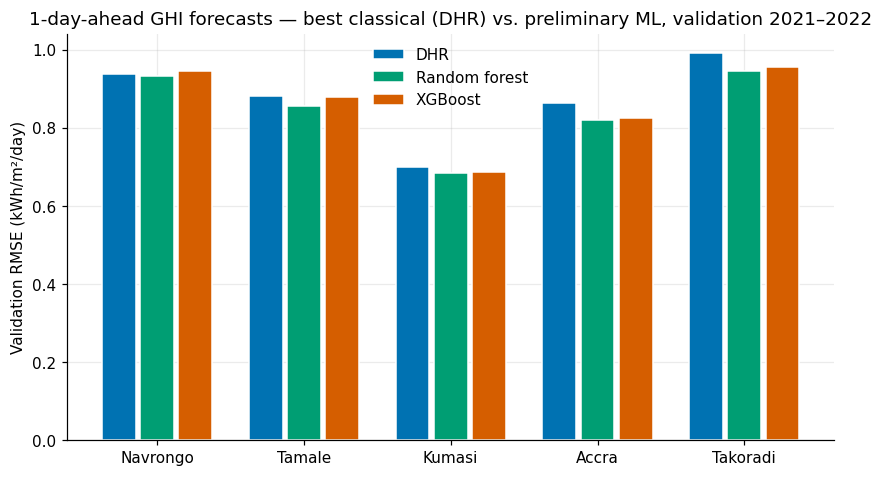

In [5]:
MODEL_COLOR = {'DHR': '#0072B2', 'Random forest': '#009E73', 'XGBoost': '#D55E00'}
fig, ax = plt.subplots(figsize=(9, 4.8))
xs = np.arange(len(SITE_ORDER))
width = 0.26
plot_models = ['DHR', 'Random forest', 'XGBoost']
for i, model in enumerate(plot_models):
    if model == 'DHR':
        vals = [dhr[dhr['Site'] == SITE_LABEL[k]]['DHR RMSE'].iloc[0] for k in SITE_ORDER]
    else:
        vals = [ml[(ml['Site'] == SITE_LABEL[k]) & (ml['Model'] == model)]['RMSE'].iloc[0]
                for k in SITE_ORDER]
    ax.bar(xs + (i - 1) * width, vals, width - 0.03, color=MODEL_COLOR[model],
           label=model, edgecolor='white', linewidth=1)
ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
ax.set_ylabel('Validation RMSE (kWh/m²/day)')
ax.set_title('1-day-ahead GHI forecasts — best classical (DHR) vs. preliminary ML, validation 2021–2022')
ax.legend(frameon=False)
fig.savefig(FIGDIR / 'fig_05_1_ml_vs_dhr.png')
plt.show()

### Figure 5-2 — XGBoost feature importance (preliminary RQ2 signal)

Gain-based importances from the tuned XGBoost per site (SHAP on the test set
follows in notebook 06).

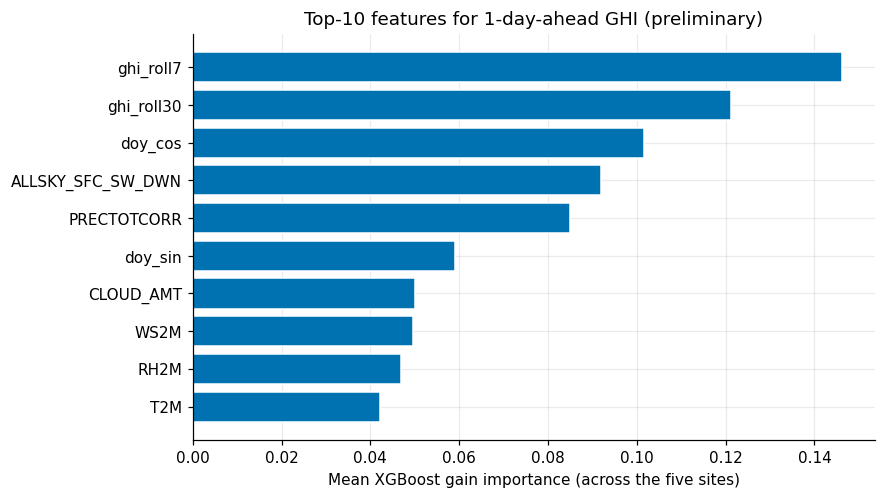

,Navrongo,Tamale,Kumasi,Accra,Takoradi
ALLSKY_SFC_SW_DWN,0.109,0.076,0.071,0.063,0.140
ghi_lag1,0.040,0.040,0.028,0.034,0.040
ghi_lag2,0.034,0.034,0.032,0.047,0.043
ghi_lag3,0.041,0.032,0.025,0.033,0.048
ghi_lag4,0.031,0.030,0.027,0.035,0.039
ghi_lag5,0.030,0.028,0.024,0.034,0.041
ghi_lag6,0.031,0.032,0.024,0.034,0.039
ghi_roll7,0.055,0.237,0.277,0.108,0.054
ghi_roll30,0.118,0.139,0.206,0.094,0.049
T2M,0.046,0.034,0.026,0.054,0.052


In [6]:
imp = pd.DataFrame(importances)[SITE_ORDER]
imp.columns = [SITE_LABEL[k] for k in SITE_ORDER]
imp_mean = imp.mean(axis=1).sort_values(ascending=True)
top = imp_mean.tail(10)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(range(len(top)), top.values, color='#0072B2', edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.set_xlabel('Mean XGBoost gain importance (across the five sites)')
ax.set_title('Top-10 features for 1-day-ahead GHI (preliminary)')
fig.savefig(FIGDIR / 'fig_05_2_feature_importance.png')
plt.show()

imp.round(3).to_csv(RESULTS / 'ml_feature_importance_1day.csv')
imp.round(3)

**Interpretation (preliminary RQ1 evidence).**

1. **Both ML models beat the best classical baseline at 4–5 of the 5 sites, but the
   margins are modest so far.** Random forest edges XGBoost everywhere and improves
   on DHR by 0.5–5.0% RMSE (largest gains: Accra 5.0%, Takoradi 4.7%; smallest:
   Navrongo 0.5%, where XGBoost is 0.7% *behind* DHR). This is well short of the
   ≥ 15% target — an important honest interim finding.
2. **Against the weak persistence baseline the picture matches the literature:**
   RF reduces RMSE by ≈ 23–28% (e.g., Accra 1.133 → 0.820, −27.6%; Kumasi
   0.911 → 0.686, −24.7%). Published tropical LSTM studies reporting 18–34% error
   reductions typically benchmark against persistence-type baselines, so the gap
   between "vs. persistence" and "vs. DHR" is expected: **most 1-day predictability
   in daily GHI is seasonal, and DHR already captures it.** The ML challenge is
   forecasting the *anomaly* — where gains are small but real, and largest at the
   cloudier southern sites where anomalies matter most.
3. **Feature importances (Figure 5-2) foreshadow RQ2:** recent GHI history
   (7- and 30-day rolling means, today's GHI) and the day-of-year harmonics carry
   most weight, with precipitation and cloud amount the leading same-day
   meteorological inputs — consistent with the EDA correlation ordering
   (notebook 03). Formal SHAP analysis on the untouched test set follows in
   notebook 06.

## 5.4 Still pending (final report)

- **LSTM** on 30-day windows (the third ML model in the synopsis).
- **7-day horizon** for RF/XGBoost/LSTM — where DHR collapses to climatology, so
  the room for ML skill may differ from the 1-day picture.
- **Broader hyperparameter search** (deeper grids, early stopping for XGBoost).
- Then **notebook 06**: final test-set (2023–2024) evaluation, Diebold–Mariano
  significance tests vs. DHR (RQ1), SHAP (RQ2), and seasonal/zonal stratification
  (RQ3).

Outputs saved: `results/ml_1day_metrics.csv`, `results/ml_vs_dhr_1day.csv`,
`results/ml_feature_importance_1day.csv`, and figures `fig_05_1`, `fig_05_2`.